# Model 2 — Length of Stay Prediction

**Dataset:** `healthcare_admissions.csv` (55,500 hospital admission records — same source as Model 1)

**Target:** `Length_of_Stay` = `Discharge Date` − `Date of Admission`, in days. This is a real, directly computable field (not a proxy), unlike the readmission label in Model 1.

Algorithms: **Linear Regression, Random Forest Regressor**
Evaluation: **RMSE, MAE, R² Score**

*Author: Nusrat — Data Analyst @ Wmolex | Educator, Gurukul Institute of Advanced Technology*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42


## 1. Load Data

In [2]:
df = pd.read_csv('healthcare_admissions.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [3]:
df.info()
print("\nMissing values:")
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB

Missing v

## 2. Compute the Target — Length of Stay

In [4]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Length_of_Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

print(df['Length_of_Stay'].describe())


count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length_of_Stay, dtype: float64


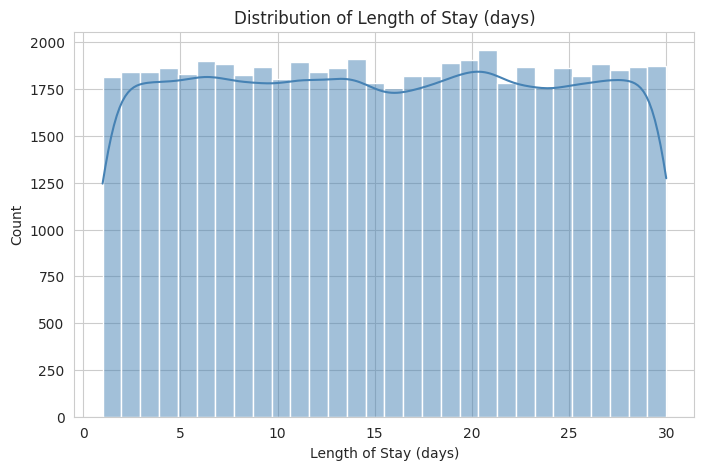

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Length_of_Stay'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Length of Stay (days)')
plt.xlabel('Length of Stay (days)')
plt.show()


## 3. Feature Engineering

- `Admission_Year`, `Admission_Month`, `Admission_DayOfWeek` extracted from `Date of Admission` for seasonal/weekday signal
- Raw identifiers (`Name`, `Doctor`, `Hospital`, `Room Number`) dropped — not generalizable predictors
- Raw date columns dropped after deriving features and the target (to avoid leaking `Discharge Date`, which was used to compute `Length_of_Stay` directly)


In [6]:
df_fe = df.copy()
df_fe['Admission_Year'] = df_fe['Date of Admission'].dt.year
df_fe['Admission_Month'] = df_fe['Date of Admission'].dt.month
df_fe['Admission_DayOfWeek'] = df_fe['Date of Admission'].dt.dayofweek

df_fe = df_fe.drop(columns=['Name', 'Doctor', 'Hospital', 'Room Number',
                             'Date of Admission', 'Discharge Date'])
df_fe.head()


,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results,Length_of_Stay,Admission_Year,Admission_Month,Admission_DayOfWeek
0,30,Male,B-,Cancer,Blue Cross,18856.281306,Urgent,Paracetamol,Normal,2,2024,1,2
1,62,Male,A+,Obesity,Medicare,33643.327287,Emergency,Ibuprofen,Inconclusive,6,2019,8,1
2,76,Female,A-,Obesity,Aetna,27955.096079,Emergency,Aspirin,Normal,15,2022,9,3
3,28,Female,O+,Diabetes,Medicare,37909.782410,Elective,Ibuprofen,Abnormal,30,2020,11,2
4,43,Female,AB+,Cancer,Aetna,14238.317814,Urgent,Penicillin,Abnormal,20,2022,9,0


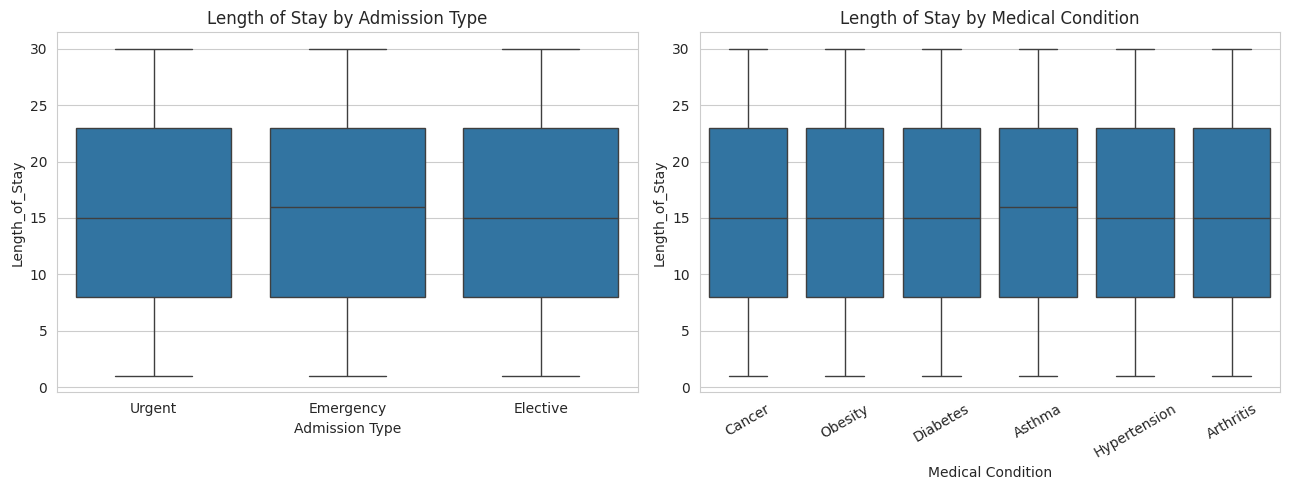

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df_fe, x='Admission Type', y='Length_of_Stay', ax=axes[0])
axes[0].set_title('Length of Stay by Admission Type')

sns.boxplot(data=df_fe, x='Medical Condition', y='Length_of_Stay', ax=axes[1])
axes[1].set_title('Length of Stay by Medical Condition')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## 4. Preprocessing Pipeline

In [8]:
target = 'Length_of_Stay'
X = df_fe.drop(columns=[target])
y = df_fe[target]

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']
Numeric columns: ['Age', 'Billing Amount', 'Admission_Year', 'Admission_Month', 'Admission_DayOfWeek']


In [9]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])


## 5. Train / Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (44400, 12), Test shape: (11100, 12)


## 6. Train Models — Linear Regression & Random Forest Regressor

In [11]:
models = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
}

fitted_pipelines = {}
pred_results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    preds = pipe.predict(X_test)
    pred_results[name] = preds
    print(f"{name} trained.")


LinearRegression trained.


RandomForestRegressor trained.


## 7. Evaluation — RMSE, MAE, R² Score

In [12]:
metrics_rows = []
for name, preds in pred_results.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    metrics_rows.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2})

metrics_df = pd.DataFrame(metrics_rows).set_index('Model').sort_values('RMSE')
metrics_df.round(4)


,RMSE,MAE,R2 Score
Model,,,
RandomForestRegressor,8.2138,6.9657,0.0938
LinearRegression,8.6320,7.4821,-0.0008


In [13]:
best_model_name = metrics_df.index[0]
best_pipeline = fitted_pipelines[best_model_name]
best_preds = pred_results[best_model_name]

print(f"Best model by RMSE: {best_model_name}")
print(f"RMSE: {metrics_df.loc[best_model_name, 'RMSE']:.4f}")
print(f"MAE:  {metrics_df.loc[best_model_name, 'MAE']:.4f}")
print(f"R2:   {metrics_df.loc[best_model_name, 'R2 Score']:.4f}")


Best model by RMSE: RandomForestRegressor
RMSE: 8.2138
MAE:  6.9657
R2:   0.0938


### Model Comparison — Bar Chart

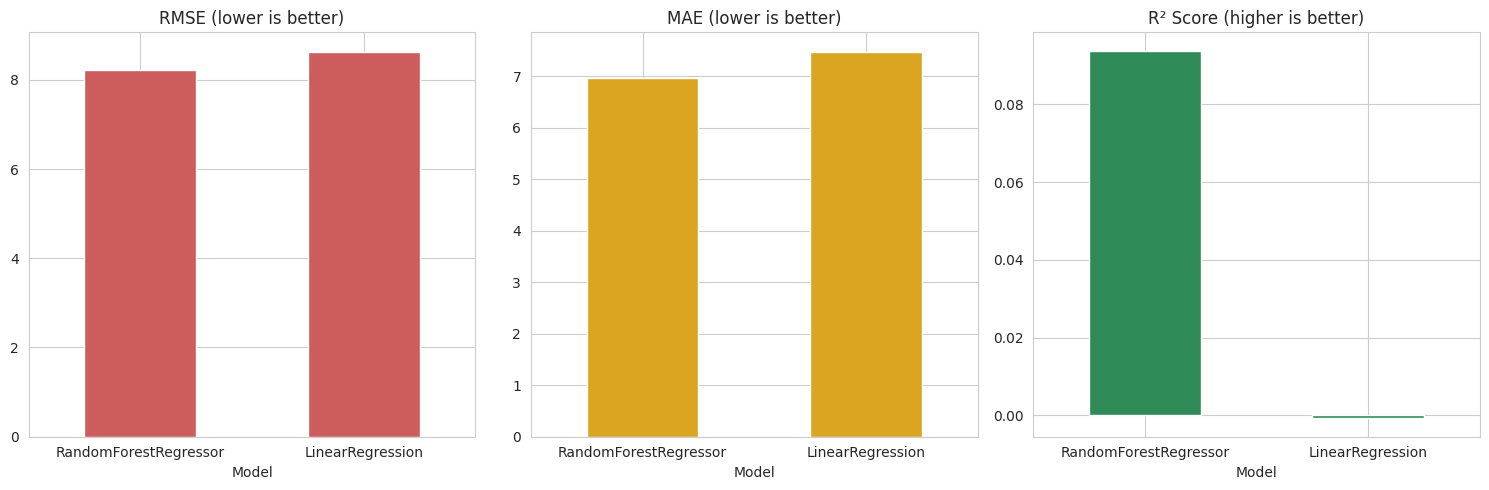

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_df['RMSE'].plot(kind='bar', ax=axes[0], color='indianred')
axes[0].set_title('RMSE (lower is better)')
axes[0].tick_params(axis='x', rotation=0)

metrics_df['MAE'].plot(kind='bar', ax=axes[1], color='goldenrod')
axes[1].set_title('MAE (lower is better)')
axes[1].tick_params(axis='x', rotation=0)

metrics_df['R2 Score'].plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('R² Score (higher is better)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### Predicted vs. Actual — Best Model

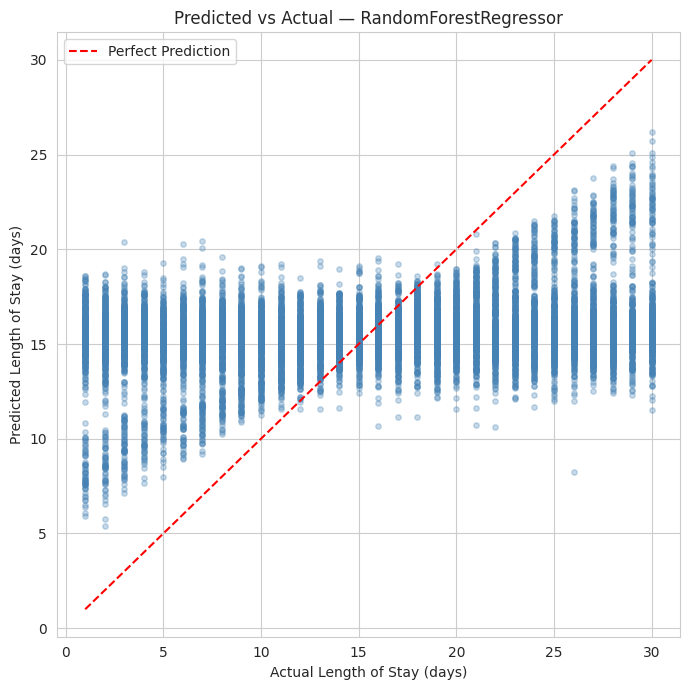

In [15]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_preds, alpha=0.3, s=15, color='steelblue')
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, 'r--', label='Perfect Prediction')
plt.xlabel('Actual Length of Stay (days)')
plt.ylabel('Predicted Length of Stay (days)')
plt.title(f'Predicted vs Actual — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.show()


### Residuals Plot — Best Model

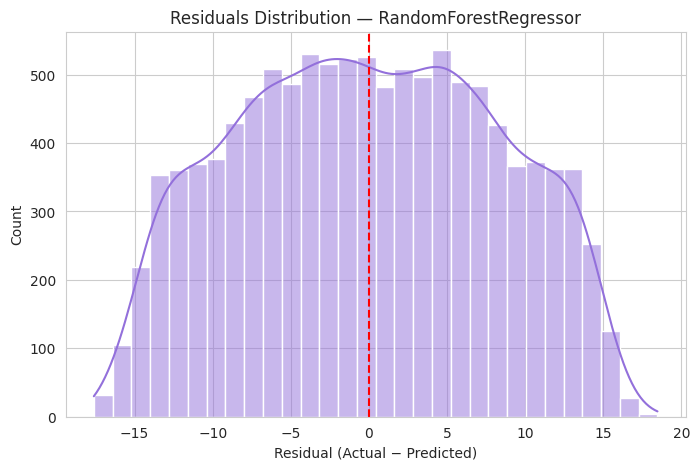

In [16]:
residuals = y_test - best_preds

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True, color='mediumpurple')
plt.axvline(0, color='red', linestyle='--')
plt.title(f'Residuals Distribution — {best_model_name}')
plt.xlabel('Residual (Actual − Predicted)')
plt.show()


## 8. Feature Importance (Random Forest)

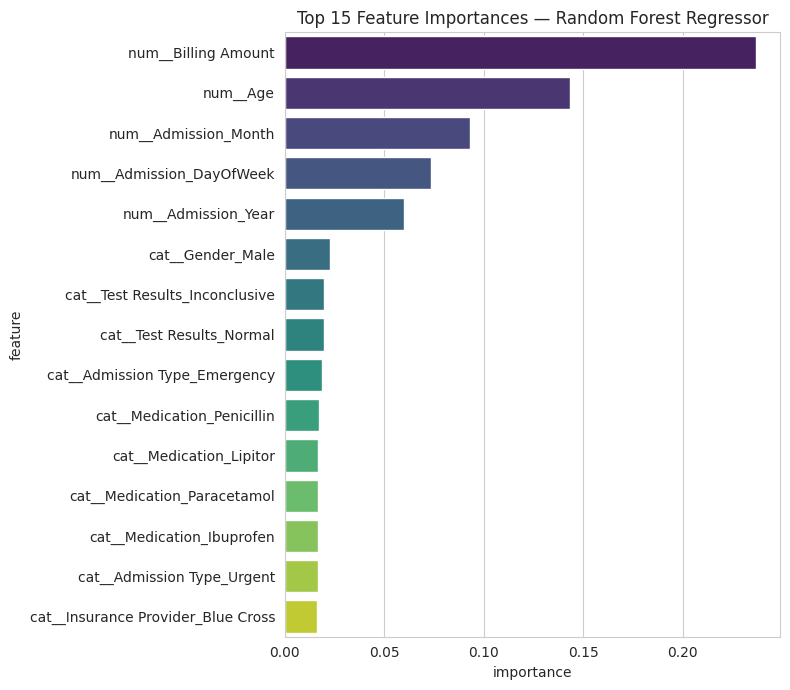

In [17]:
def get_feature_names(pipeline):
    return pipeline.named_steps['preprocessor'].get_feature_names_out()

rf_pipeline = fitted_pipelines['RandomForestRegressor']
importances = rf_pipeline.named_steps['regressor'].feature_importances_
feat_names = get_feature_names(rf_pipeline)

fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 7))
sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances — Random Forest Regressor')
plt.tight_layout()
plt.show()


## 9. Summary

- `Length_of_Stay` is a directly computed target (discharge date − admission date), not a proxy — more reliable ground truth than Model 1's readmission label.
- Linear Regression and Random Forest Regressor were compared on identical preprocessing and the same 20% held-out split.
- Best model selected by **RMSE**, with MAE and R² reported alongside for a fuller picture of fit quality.
- Predicted-vs-actual and residuals plots above show how well (or how loosely) length of stay can be predicted from the available admission-level features — R² here reflects how much variance these features actually explain, which is worth calling out honestly if it's low (synthetic/randomized fields like `Medical Condition` and `Admission Type` may carry limited real signal for stay duration in this dataset).
